# Target-tenor skew diagnostics

Build the screened, arbitrage-aware Raw SVI surface for the current SPX quote date, apply the calendar repair, and extract 30D, 60D, and 90D smiles. A tenor is valid only if the fixed $k=-0.10$ to $+0.10$ range is supported and passes the sampled call-price slope and convexity checks. Failed smiles remain plotted over available support and their metrics are left missing.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.raw_svi import fit_raw_svi_surface
from src.skew_metrics import calculate_skew_metrics
from src.vol_surface import build_total_variance_grid, enforce_calendar_monotonicity

PANEL_PATH = ROOT / 'data/processed/spx_iv_panel_2025-08-29.csv'
panel = pd.read_csv(PANEL_PATH, parse_dates=['quote_date', 'expiry_date'])
fit = fit_raw_svi_surface(panel, enforce_arbitrage=True)
surface_grid = build_total_variance_grid(fit['parameters_by_expiry'])
surface_grid['repaired_total_variance'] = enforce_calendar_monotonicity(
    surface_grid['raw_total_variance']
)
quote_date = panel['quote_date'].iloc[0]
results = calculate_skew_metrics(surface_grid, quote_date)
metrics = results['metrics']
smiles = results['smiles']
print(f'Quote date: {quote_date:%Y-%m-%d}; target tenors: {len(metrics)}')

Quote date: 2025-08-29; target tenors: 3


## 30D, 60D, and 90D smiles

The vertical guides mark the two fixed-skew points and ATM. Dashed lines indicate a tenor that failed the support or convexity quality check; its available smile is shown for inspection.

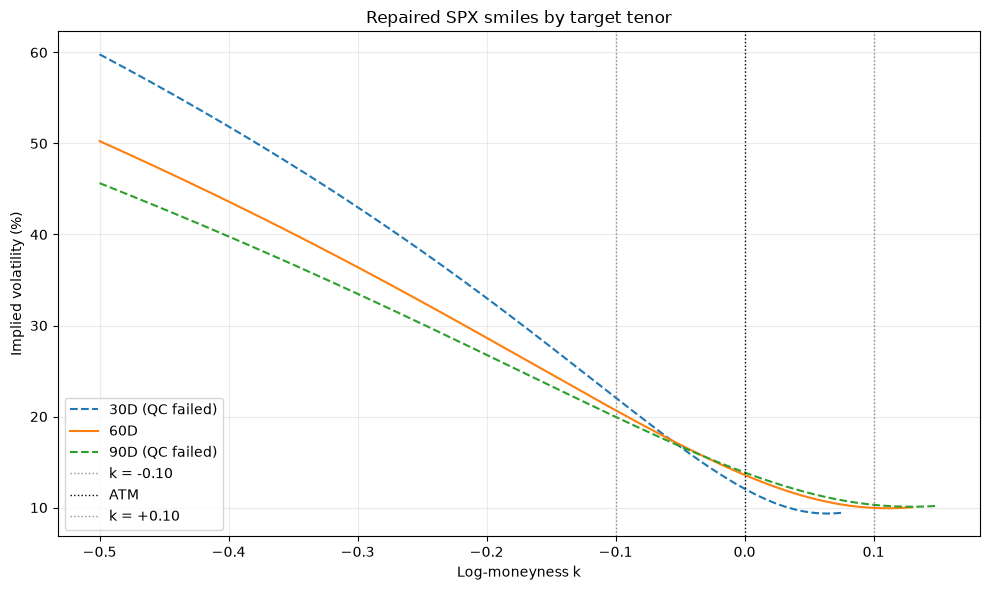

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = {30: 'tab:blue', 60: 'tab:orange', 90: 'tab:green'}
for row in metrics.itertuples(index=False):
    tenor_smile = smiles.loc[smiles['target_days'].eq(row.target_days)]
    if tenor_smile.empty:
        ax.plot([], [], color=colors[row.target_days], label=f'{row.target_days}D (unavailable)')
        continue
    label = f'{row.target_days}D' if row.surface_valid else f'{row.target_days}D (QC failed)'
    ax.plot(
        tenor_smile['log_moneyness'], 100 * tenor_smile['implied_volatility'],
        color=colors[row.target_days], linestyle='-' if row.surface_valid else '--',
        label=label,
    )
for k, label, color in [(-0.10, 'k = -0.10', '0.55'), (0.0, 'ATM', 'black'), (0.10, 'k = +0.10', '0.55')]:
    ax.axvline(k, color=color, linestyle=':', linewidth=1, label=label)
ax.set(xlabel='Log-moneyness k', ylabel='Implied volatility (%)', title='Repaired SPX smiles by target tenor')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## Skew measures and quality flags

ATM slope is the centered finite difference $[\sigma(0.01)-\sigma(-0.01)]/0.02$, reported in volatility percentage points per unit $k$. Fixed-$k$ skew is $\sigma(-0.10)-\sigma(+0.10)$, reported in volatility points. A positive skew means the put-side IV is higher than the call-side IV. Invalid tenors have missing metrics and include the QC reason.

In [3]:
display(metrics.assign(
    quote_date=metrics['quote_date'].dt.strftime('%Y-%m-%d'),
    atm_iv_percent=100 * metrics['atm_iv'],
    fixed_k_skew_vol_points=100 * metrics['fixed_k_skew'],
    atm_slope_vol_points_per_k=100 * metrics['atm_slope'],
)[['quote_date', 'target_days', 'atm_iv_percent', 'fixed_k_skew_vol_points',
   'atm_slope_vol_points_per_k', 'surface_valid', 'convexity_valid', 'failure_reason']].round(5))

valid = metrics.loc[metrics['surface_valid']]
assert metrics['target_days'].tolist() == [30, 60, 90]
assert metrics.loc[~metrics['surface_valid'], ['atm_iv', 'fixed_k_skew', 'atm_slope']].isna().all().all()
assert valid['atm_iv'].gt(0).all()
assert np.isfinite(valid[['atm_iv', 'fixed_k_skew', 'atm_slope']].to_numpy()).all()
print(f'Valid target tenors: {len(valid)} / {len(metrics)}')
print('Positive fixed-k skew means IV(-0.10) > IV(+0.10); negative means the reverse.')
print('Positive ATM slope means IV rises toward positive k; negative means it falls.')
print('Skew magnitude in volatility points:', (100 * valid['fixed_k_skew']).abs().describe().round(4).to_dict())
print('ATM IV in percent:', (100 * valid['atm_iv']).describe().round(4).to_dict())

,quote_date,target_days,atm_iv_percent,fixed_k_skew_vol_points,atm_slope_vol_points_per_k,surface_valid,convexity_valid,failure_reason
0,2025-08-29,30,NaN,NaN,NaN,False,False,requested_range_not_supported
1,2025-08-29,60,13.58876,10.73125,-59.65083,True,True,
2,2025-08-29,90,NaN,NaN,NaN,False,True,call_slope_bounds


Valid target tenors: 1 / 3
Positive fixed-k skew means IV(-0.10) > IV(+0.10); negative means the reverse.
Positive ATM slope means IV rises toward positive k; negative means it falls.
Skew magnitude in volatility points: {'count': 1.0, 'mean': 10.7313, 'std': nan, 'min': 10.7313, '25%': 10.7313, '50%': 10.7313, '75%': 10.7313, 'max': 10.7313}
ATM IV in percent: {'count': 1.0, 'mean': 13.5888, 'std': nan, 'min': 13.5888, '25%': 13.5888, '50%': 13.5888, '75%': 13.5888, 'max': 13.5888}
